# DATA LOAD & OVERVIEW

- First 5 rows and Shape of this dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("healthcare.csv")


print("First 5 rows:\n",df.head(5))
print("\nShape:\n",df.shape)

First 5 rows:
             Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    1

- total null values

In [2]:
print("\nTotal null values:\n",df.isnull().sum())


Total null values:
 Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


- info of the dataset

In [3]:
print("\ninfo:\n")
df.info()


info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory us

- checking values if there is any inconsistency in the values

In [4]:
print("\nValues of admission type:\n",df["Admission Type"].unique())
print("\nValues of medical conditions:\n",df["Medical Condition"].unique())
print("\nValues of Insurance Providers:\n",df["Insurance Provider"].unique())
print("\nValues of Medications:\n",df["Medication"].unique())
print("\nValues of Test Results:\n",df["Test Results"].unique())
print("\nValues of Gender:\n",df["Gender"].unique())



Values of admission type:


 ['Urgent' 'Emergency' 'Elective']

Values of medical conditions:
 ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']

Values of Insurance Providers:
 ['Blue Cross' 'Medicare' 'Aetna' 'UnitedHealthcare' 'Cigna']

Values of Medications:
 ['Paracetamol' 'Ibuprofen' 'Aspirin' 'Penicillin' 'Lipitor']

Values of Test Results:
 ['Normal' 'Inconclusive' 'Abnormal']

Values of Gender:
 ['Male' 'Female']


# DATA PREPROCESSING AND CLEANING

- changing the datatypes of date of admission and discharge date from object to datetime

In [5]:
print("\nDate of Admission Datatype before changing:",df["Date of Admission"].dtype)
df["Date of Admission"]=pd.to_datetime(df["Date of Admission"])
print("Date of Admission Datatype after changing:",df["Date of Admission"].dtype)

print("\nDischarge Date Datatype before changing:",df["Discharge Date"].dtype)
df["Discharge Date"]=pd.to_datetime(df["Discharge Date"])
print("Discharge Date Datatype after changing:",df["Discharge Date"].dtype)


Date of Admission Datatype before changing: object
Date of Admission Datatype after changing: datetime64[ns]

Discharge Date Datatype before changing: object
Discharge Date Datatype after changing: datetime64[ns]


- Fixing the Name Column's values

In [6]:
print("\nBefore Cleaning:\n",df["Name"].head())
df['Name'] = df['Name'].str.title()
print("\nAfter Cleaning:\n",df["Name"].head())


Before Cleaning:
 0    Bobby JacksOn
1     LesLie TErRy
2      DaNnY sMitH
3     andrEw waTtS
4    adrIENNE bEll
Name: Name, dtype: object

After Cleaning:
 0    Bobby Jackson
1     Leslie Terry
2      Danny Smith
3     Andrew Watts
4    Adrienne Bell
Name: Name, dtype: object


- Removing Duplicate Values

In [7]:
print("\nDuplicate Values Before Cleaning:",df.duplicated().sum())
df=df.drop_duplicates()
print("\nDuplicate Values After Cleaning:",df.duplicated().sum())


Duplicate Values Before Cleaning: 534

Duplicate Values After Cleaning: 0


In [8]:
df['Hospital'] = (
    df['Hospital']
    .str.replace(r'^and\s+', '', regex=True)  # only remove "and" at start
    .str.replace(',', '', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# FEATURE ENGINEERING

- Adding Admission Year & Month + Discharge Year & Month

In [9]:
df["Admission Year"]=df["Date of Admission"].dt.year
df["Admission Month"]=df["Date of Admission"].dt.month

df["Discharge Year"]=df["Discharge Date"].dt.year
df["Discharge Month"]=df["Discharge Date"].dt.month

- Adding Length Of Stay Column and checking if any negative or over large duration exists or not

In [50]:
df["Length of Stay"]=(df["Discharge Date"]-df["Date of Admission"]).dt.days
print(df["Length of Stay"].head(10))


0     2
1     6
2    15
3    30
4    20
5     4
6    12
7    10
8    13
9    30
Name: Length of Stay, dtype: int64


In [51]:
print("\nNegative Values in length of stay:\n",df[df["Length of Stay"]<1])   # check if any negative value is there or not


Negative Values in length of stay:
 Empty DataFrame
Columns: [Name, Age, Gender, Blood Type, Medical Condition, Date of Admission, Doctor, Hospital, Insurance Provider, Billing Amount, Room Number, Admission Type, Discharge Date, Medication, Test Results, Admission Year, Admission Month, Discharge Year, Discharge Month, Length of Stay, Age Group]
Index: []

[0 rows x 21 columns]


In [53]:
print("\nMaximun length of stay:\n",df["Length of Stay"].max())
print("\nMinimum length of stay:\n",df["Length of Stay"].min())


Maximun length of stay:
 30

Minimum length of stay:
 1


- adding age group column

In [ ]:
df["Age Group"]=pd.cut(df["Age"],bins=[0,13,19,27,51,100],labels=["Child","Teenage","Young Adult","Adult","Senior Citizen"],right=False)

# Exploratory Data Analysis

In [12]:
print("\nTotal Male and Female:\n",df["Gender"].value_counts())
print("\nMost number of blood groups:\n",df["Blood Type"].value_counts())   
# A- Blood type has highest number of patients, lowest number of patients has O-.
# Each blood groups have 6000+ patients
print("\nNumber of patients by medical condition:\n",df["Medical Condition"].value_counts()) 
# Most of the patients are dealing with Arthritis, Diabetes ranks 2nd just by a difference of 2. 


Total Male and Female:
 Gender
Male      27496
Female    27470
Name: count, dtype: int64

Most number of blood groups:
 Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64

Number of patients by medical condition:
 Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64


- There is no big difference between the total number of male & female. 
- Almost every Blood Type is available here and have more than 6500 people in each type.
- For each medical condition there is 9000+ patients, Arthritis is the most (9218).

#### top 10 most appointed doctors

In [13]:
print("Top 10 most appointed doctors:\n",df["Doctor"].value_counts().head(10))

Top 10 most appointed doctors:
 Doctor
Michael Smith        27
John Smith           22
Robert Smith         21
James Smith          20
Michael Johnson      20
David Smith          19
Robert Johnson       19
Michael Williams     18
Matthew Smith        17
Christopher Smith    17
Name: count, dtype: int64


#### Top Insurance Providing Company

In [14]:
print("Top insurance provider:\n",df["Insurance Provider"].value_counts())
# Cigna is top insurace provider according to number of users

Top insurance provider:
 Insurance Provider
Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: count, dtype: int64


- Every insurance provider has 10000+ patients, but Most patients (11139) has choseen Cigna as their Insurance Provider.

#### Most preferred Medication

In [15]:
print("Most preferred Mediction:\n",df["Medication"].value_counts())
# Lipitor with 11038 & Ibuprofen with 11023 preferrences are the top 2 most preferred medications.

Most preferred Mediction:
 Medication
Lipitor        11038
Ibuprofen      11023
Aspirin        10984
Paracetamol    10965
Penicillin     10956
Name: count, dtype: int64


- Most Test Results

In [16]:
print("Most Test Results:\n",df["Test Results"].value_counts())

Most Test Results:
 Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64


In [17]:
print("Most Admission Types:\n",df["Admission Type"].value_counts())

Most Admission Types:
 Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64


- Most patients has been admitted as an Elective type, where Urgent Admission ranked 2nd and Emergency ranked 3rd.

#### Finding most pateint in age group and in that which condition of patients are most 

In [60]:
age_grp=df["Age Group"].value_counts()
age_grp=age_grp[age_grp>0]
print("Most patients according to age group:\n",age_grp)

Most patients according to age group:
 Age Group
Senior Citizen    28394
Adult             19281
Young Adult        6405
Teenage             886
Name: count, dtype: int64


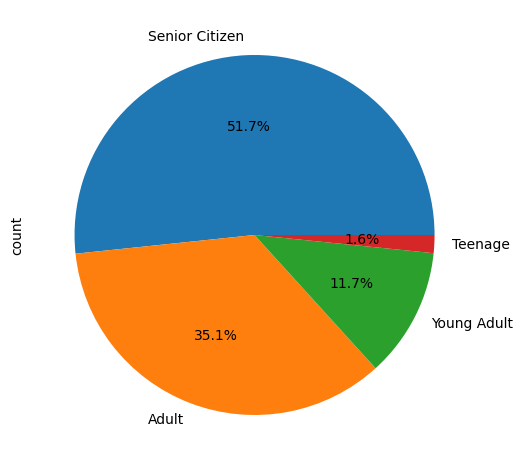

In [61]:
pivot=age_grp
pivot.plot(kind="pie",autopct="%1.1f%%")
plt.tight_layout()
plt.show()

In [20]:
df_sen=df[df["Age Group"]=="Senior Citizen"]
sen_cit_med_con=df_sen["Medical Condition"].value_counts()
print(sen_cit_med_con)

Medical Condition
Hypertension    4763
Diabetes        4763
Arthritis       4745
Cancer          4737
Asthma          4696
Obesity         4690
Name: count, dtype: int64


- Senior citizens were the most patients. In senior citizens hypertension and diabetes ranked equally. Senior citizens may deal with hypertension and diabetes and arthritis too, due to a combination of natural physiological aging, long-term lifestyle factors, and the increased likelihood of co-existing, age-related chronic conditions.

In [ ]:
age_med= df.groupby(['Age Group', 'Medical Condition'],observed=True).size().unstack()
print(age_med)
print("\nTop medical condtions:\n",age_med.idxmax(axis=1))

Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Age Group                                                                    
Teenage                  149     150     146       140           143      158
Young Adult             1065    1066    1061      1069          1067     1077
Adult                   3259    3183    3196      3244          3178     3221
Senior Citizen          4745    4696    4737      4763          4763     4690

Top medical condtions:
 Age Group
Teenage             Obesity
Young Adult         Obesity
Adult             Arthritis
Senior Citizen     Diabetes
dtype: object


- in teenagers and young adults Obesity is most affected condition. This indicates how much careless they are towards fitness. It may happen if most of the time they spend time home instead of playing outside or doing physical activities. This can cause many more serious disease in future.
- in adults the risk of Arthritis is at high. Obesity is a major cause of Arthritis, those who are already going through obesity they may suffer from arthritis too if they dont get serious about fitness. In upcoming years, the arthritis rate will may be rise more. 

#### No of medical conditions as per gender

In [21]:
gen_med= df.groupby(['Gender', 'Medical Condition']).size().unstack()
print(gen_med)
print("\nTop medical condtions:\n",gen_med.idxmax(axis=1))

Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Gender                                                                       
Female                  4642    4511    4566      4609          4569     4573
Male                    4576    4584    4574      4607          4582     4573

Top medical condtions:
 Gender
Female    Arthritis
Male       Diabetes
dtype: object


- Most females are suffering from arthritis, this is a common problem for many womens. This may happen due to hormonal changes, anatomy, joint laxity and more. Studies suggest that women may experience higher pain intensity and more widespread pain than men with the same level of joint damage.

### medical conditions as per blood group

In [66]:
med_blood=df.groupby(['Medical Condition','Blood Type']).size().unstack()
print(med_blood)
print("\nTop Group in each medical condition:\n",med_blood.idxmax(axis=1))

Blood Type           A+    A-   AB+   AB-    B+    B-    O+    O-
Medical Condition                                                
Arthritis          1107  1144  1124  1179  1191  1152  1186  1135
Asthma             1124  1162  1173  1123  1104  1108  1162  1139
Cancer             1171  1124  1100  1186  1186  1131  1098  1144
Diabetes           1201  1154  1165  1132  1180  1136  1142  1106
Hypertension       1123  1186  1204  1108  1087  1163  1145  1135
Obesity            1170  1128  1116  1146  1137  1182  1122  1145

Top Group in each medical condition:
 Medical Condition
Arthritis        B+
Asthma          AB+
Cancer          AB-
Diabetes         A+
Hypertension    AB+
Obesity          B-
dtype: object


- there is no huge difference between each blood group numbers as per medical condition. Its more likely that blood types doesnt effect much in medical conditions of this dataset. But research indicates that blood groups (ABO system) can be associated with varying susceptibility to hypertension, diabetes, and obesity, although they are not the primary cause of these conditions.

### Total Admission per year

In [67]:
ad_per_year=df.groupby('Admission Year')['Name'].count()
print("\nMost Patients in each year:\n",ad_per_year.sort_values(ascending=False))


Most Patients in each year:
 Admission Year
2020    11172
2023    10936
2022    10915
2021    10816
2019     7300
2024     3827
Name: Name, dtype: int64


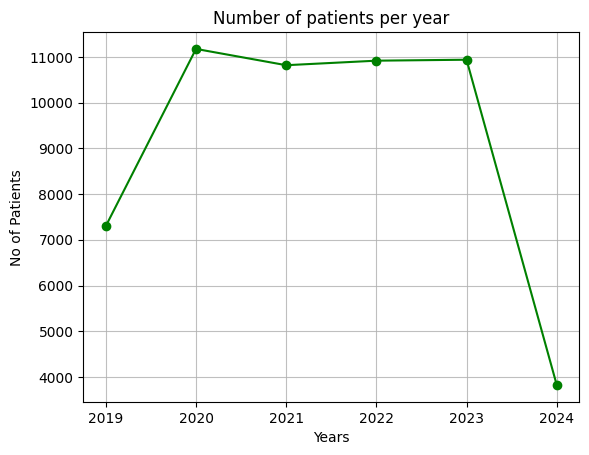

In [24]:
pivot=ad_per_year
pivot.plot(kind="line",color="green",marker="o")
plt.xlabel("Years")
plt.ylabel("No of Patients")
plt.grid(alpha=0.8)
plt.title("Number of patients per year")
plt.show()

- In 2020, most patients were admitted. As this was the corona outbreak moment, all of the available medical conditions in this dataset are can be directly affected due to Corona. Due to lack of Covid test info in this dataset this cannot be said directly that how many patients were affected more after or before corona. 
- But diabetes and asthma patients were at higher risk due to corona, obesity patients have low immune systems which can cause of getting affected by corona more easily, also for cancer patients. Hypertension was very common risk factor among hospitalized COVID-19 patients, nearly doubling the risk of severe illness or death. 
- Chance of long covid: People with pre-existing conditions like hypertension and diabetes also have a 2-3 times higher risk of suffering from "Long Covid," where symptoms last for months.
- Even after 2020, number of patients were almost same for next 3 years. Many covid patients can get affected by these conditions after recovering from covid, as covid makes the immune system more weak which may cause asthma, hypertension, arthrits most. 
- In 2024, the numbers finally made siginificant drop. Its more likely that people are getting about physical conditons and maintaining health better than previous year records. 

#### Analyzing numbers of medical condition by each year

In [25]:
med_con_per_year=df.groupby(['Admission Year','Medical Condition']).size().unstack()
print("\nNo of Medical Condition in each year:\n",med_con_per_year)
print("\nMost Medical Condition in each year:\n",med_con_per_year.idxmax(axis=1))


No of Medical Condition in each year:
 Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Admission Year                                                               
2019                    1187    1274    1272      1233          1175     1159
2020                    1871    1791    1882      1792          1883     1953
2021                    1827    1822    1728      1779          1849     1811
2022                    1838    1751    1809      1922          1818     1777
2023                    1806    1782    1831      1838          1829     1850
2024                     689     675     618       652           597      596

Most Medical Condition in each year:
 Admission Year
2019          Asthma
2020         Obesity
2021    Hypertension
2022        Diabetes
2023         Obesity
2024       Arthritis
dtype: object


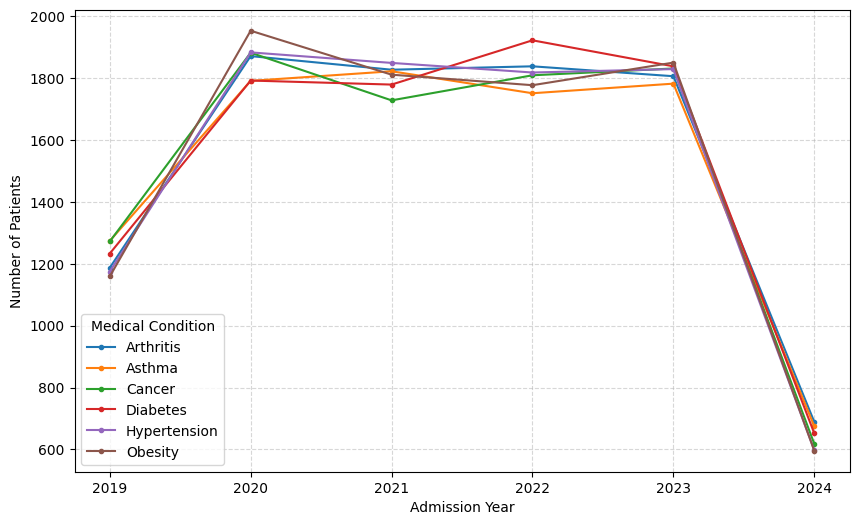

In [ ]:
pivot=med_con_per_year
pivot.plot(kind="line",marker='.',figsize=(10,6))
plt.xlabel("Admission Year")
plt.xticks(rotation=0)
plt.ylabel("Number of Patients")
plt.grid(linestyle="--",alpha=0.5)
plt.show()

- after 2020, in the next years Hypertension, diabetes, obesity, arthritis ranked most in each year. this may happen due to the corona after impact which increases the chance of getting affected by these conditions


### Test Results per year

In [27]:
res_per_year=df.groupby(["Admission Year","Test Results"]).size().unstack()
print("No of test results in each year:\n",res_per_year)
print("\nTop test results in each year:\n",res_per_year.idxmax(axis=1))


No of test results in each year:
 Test Results    Abnormal  Inconclusive  Normal
Admission Year                                
2019                2459          2396    2445
2020                3726          3740    3706
2021                3593          3579    3644
2022                3701          3512    3702
2023                3676          3703    3557
2024                1282          1268    1277

Top test results in each year:
 Admission Year
2019        Abnormal
2020    Inconclusive
2021          Normal
2022          Normal
2023    Inconclusive
2024        Abnormal
dtype: object


### test results as per medical conditions

In [28]:
med_con_res=df.groupby(["Medical Condition","Test Results"]).size().unstack()
print(med_con_res)
print("\nMost test results in each medical condition:\n",med_con_res.idxmax(axis=1))

Test Results       Abnormal  Inconclusive  Normal
Medical Condition                                
Arthritis              3156          3062    3000
Asthma                 2980          2999    3116
Cancer                 3089          3033    3018
Diabetes               3131          3024    3061
Hypertension           2977          3068    3106
Obesity                3104          3012    3030

Most test results in each medical condition:
 Medical Condition
Arthritis       Abnormal
Asthma            Normal
Cancer          Abnormal
Diabetes        Abnormal
Hypertension      Normal
Obesity         Abnormal
dtype: object


### top doctors according to medical conditions

In [29]:
top_doc_med_con=df.groupby("Medical Condition")["Doctor"].value_counts()
print("Top Doctors according to medical condition:\n",top_doc_med_con.groupby(level=0).head(1))

Top Doctors according to medical condition:
 Medical Condition  Doctor           
Arthritis          John Smith           8
Asthma             David Smith          5
Cancer             Michael Johnson      6
Diabetes           Christopher Brown    6
Hypertension       Michael Smith        7
Obesity            Andrew Williams      7
Name: count, dtype: int64


### top hospital in each year

In [30]:
top_hosp_per_year=df.groupby("Admission Year")["Hospital"].value_counts()
top_hos_per_year=top_hosp_per_year.groupby(level=0).head(1)
print("Top hospitals per year:\n",top_hos_per_year)

Top hospitals per year:
 Admission Year  Hospital   
2019            Brown Inc       8
2020            Ltd Smith      10
2021            Smith LLC      12
2022            LLC Smith      12
2023            Smith Group    12
2024            PLC Davis       6
Name: count, dtype: int64


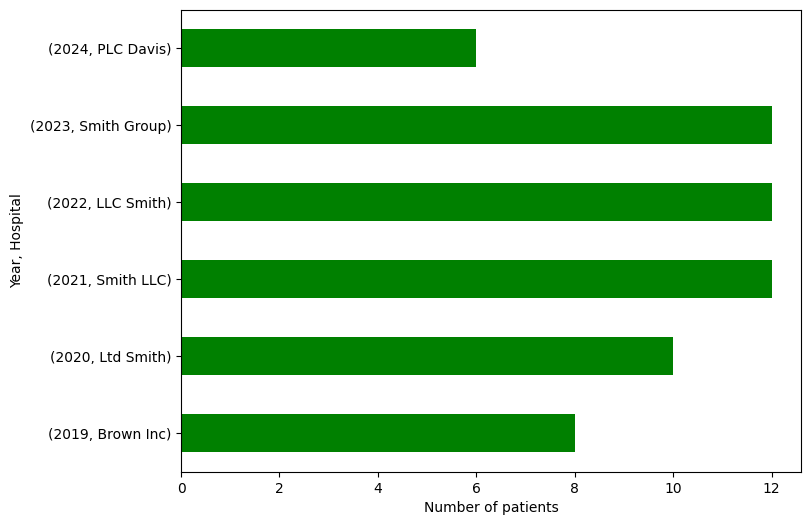

In [31]:
pivot=top_hos_per_year
pivot.plot(kind="barh",color="green",figsize=(8,6))
plt.xlabel("Number of patients")
plt.ylabel("Year, Hospital")
plt.show()

### hospital with most patients

In [32]:
top_hosp_patients=df.groupby("Hospital")["Name"].count().sort_values(ascending=False)
print("hospitals with most patients:\n",top_hosp_patients.head(10))

hospitals with most patients:
 Hospital
LLC Smith      44
Ltd Smith      39
Johnson PLC    37
Smith Ltd      37
Smith Group    36
Smith PLC      36
Johnson Inc    34
Smith Inc      33
Group Smith    32
Smith LLC      32
Name: Name, dtype: int64


### Billing amount analysis

In [34]:
avg_bill=df["Billing Amount"].mean()
print("The average billing amount is",avg_bill.round(2),"USD")

The average billing amount is 25544.31 USD


In [35]:
avg_bill_per_year=df.groupby("Admission Year")["Billing Amount"].mean()
print("The average billing amount per year is (In USD):\n",avg_bill_per_year.round(2))

The average billing amount per year is (In USD):
 Admission Year
2019    25686.44
2020    25416.46
2021    25626.69
2022    25525.61
2023    25573.41
2024    25383.71
Name: Billing Amount, dtype: float64


In [71]:
avg_bill_per_medcon=df.groupby("Medical Condition")["Billing Amount"].mean()
print("The average billing amount per medical condition is (In USD):\n",avg_bill_per_medcon.round(2))

The average billing amount per medical condition is (In USD):
 Medical Condition
Arthritis       25511.78
Asthma          25633.46
Cancer          25152.32
Diabetes        25660.48
Hypertension    25503.06
Obesity         25804.36
Name: Billing Amount, dtype: float64


In [73]:
avg_bill_per_adtype=df.groupby("Admission Type")["Billing Amount"].mean()
print("The average billing amount per admission type is (In USD):\n",avg_bill_per_adtype.round(2))

The average billing amount per admission type is (In USD):
 Admission Type
Elective     25612.14
Emergency    25505.33
Urgent       25514.53
Name: Billing Amount, dtype: float64


* The average billing amount per year & medical condition is ~25000 USD

In [36]:
top_earn_hospital=df.groupby("Hospital")["Billing Amount"].sum()
print("The most earned hospital (In USD):\n",top_earn_hospital.sort_values(ascending=False).round(2).head(10))

The most earned hospital (In USD):
 Hospital
Johnson PLC    1081477.31
LLC Smith      1030189.87
Smith PLC      1029424.45
Ltd Smith      1003365.53
Smith Ltd       970035.87
Johnson Inc     934310.73
Group Smith     902975.79
Inc Brown       877961.31
LLC Johnson     816438.35
Smith Group     806631.29
Name: Billing Amount, dtype: float64


In [37]:
top_earn_per_year=df.groupby(["Admission Year","Hospital"])["Billing Amount"].sum().sort_values(ascending=False)
top_earn_year=top_earn_per_year.groupby(level=0).head(1).round(2)
print("Top earned hospital per year is (In USD):\n",top_earn_year.sort_index(ascending=True))

Top earned hospital per year is (In USD):
 Admission Year  Hospital    
2019            LLC Johnson     243828.80
2020            Smith PLC       252636.42
2021            Johnson PLC     310726.75
2022            PLC Williams    289538.63
2023            Johnson Inc     361045.65
2024            Smith PLC       173434.93
Name: Billing Amount, dtype: float64


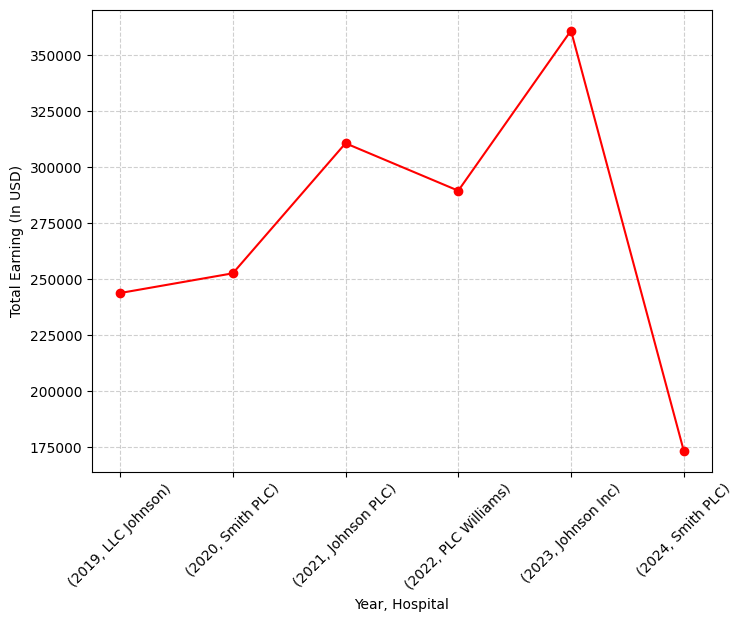

In [38]:
pivot=top_earn_year.sort_index(ascending=True)
pivot.plot(kind="line",color="red",marker="o",figsize=(8,6))
plt.xticks(rotation=45)
plt.xlabel("Year, Hospital")
plt.ylabel("Total Earning (In USD)")
plt.grid(linestyle="--",alpha=0.6)
plt.show()

In [39]:
avg_earn_per_year=df.groupby(["Admission Year","Hospital"])["Billing Amount"].mean().sort_values(ascending=True)
print("The negative net billing hospital per year is (In USD):\n",avg_earn_per_year.groupby(level=0).head(1).round(2))
print("\nNo of Hospitals whose net billing is in negtaive per year:\n",avg_earn_per_year[avg_earn_per_year<0].groupby(level=0).size())

The negative net billing hospital per year is (In USD):
 Admission Year  Hospital                    
2022            Juarez-Clark                   -2008.49
2024            Ltd Wilson                     -1520.42
2023            Group Hansen                   -1306.66
2020            Lawrence and Cooper Saunders   -1130.00
2019            Lopez-Hughes                    -857.13
2021            Brady Ward Wallace and          -824.23
Name: Billing Amount, dtype: float64

No of Hospitals whose net billing is in negtaive per year:
 Admission Year
2019    14
2020    13
2021    18
2022    14
2023    14
2024     7
Name: Billing Amount, dtype: int64


In [40]:
avg_bill_adm_type=df.groupby("Admission Type")["Billing Amount"].mean()
print("Average billing amount by admission type (In USD):\n",avg_bill_adm_type)

Average billing amount by admission type (In USD):
 Admission Type
Elective     25612.139673
Emergency    25505.332240
Urgent       25514.532045
Name: Billing Amount, dtype: float64


In [41]:
avg_stay=df["Length of Stay"].mean()
print("Average length of stay:\n",avg_stay.round(2))

Average length of stay:
 15.5


In [42]:
avg_stay_adm_type=df.groupby("Admission Type")["Length of Stay"].mean()
print(avg_stay_adm_type)

Admission Type
Elective     15.511178
Emergency    15.584134
Urgent       15.403839
Name: Length of Stay, dtype: float64


### Number of given medications by medical conditions

In [43]:
medi_med_con=df.groupby(["Medication","Medical Condition"]).size().unstack()
print(medi_med_con)
print("\nMost admission types in each medical condition:\n",medi_med_con.idxmax(axis=1))

Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Medication                                                                   
Aspirin                 1901    1781    1768      1836          1845     1853
Ibuprofen               1805    1802    1862      1846          1874     1834
Lipitor                 1810    1814    1904      1875          1823     1812
Paracetamol             1858    1870    1829      1794          1839     1775
Penicillin              1844    1828    1777      1865          1770     1872

Most admission types in each medical condition:
 Medication
Aspirin           Arthritis
Ibuprofen      Hypertension
Lipitor              Cancer
Paracetamol          Asthma
Penicillin          Obesity
dtype: object


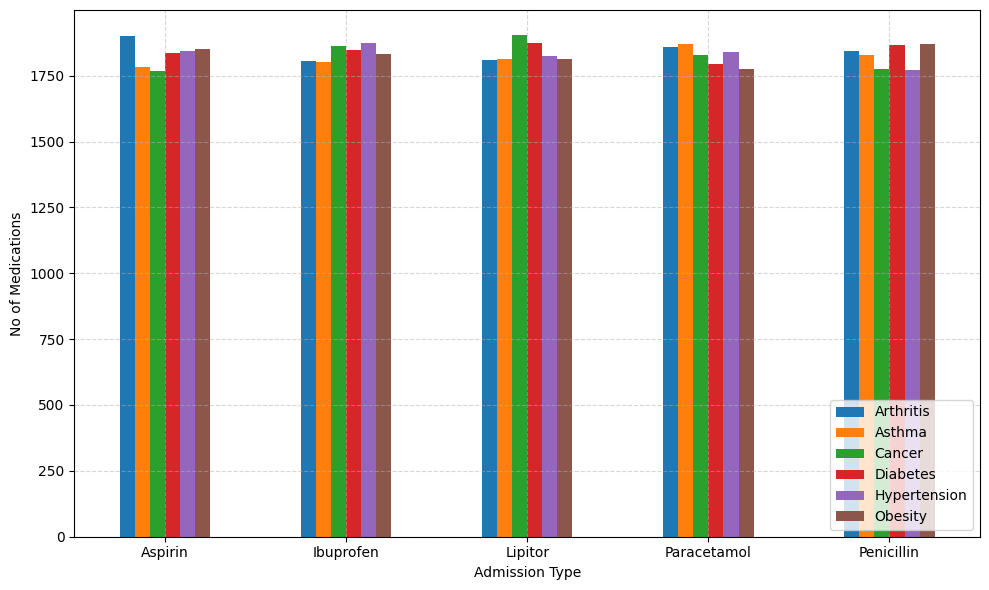

In [44]:
pivot=medi_med_con
pivot.plot(kind="bar",figsize=(10,6))
plt.xlabel("Admission Type")
plt.xticks(rotation=0)
plt.ylabel("No of Medications")
plt.legend(loc="lower right")
plt.grid(linestyle="--",alpha=0.5)
plt.tight_layout()
plt.show()

### Test Result for each medication type

In [70]:
med_by_test_res=df.groupby(["Medication","Test Results"]).size().unstack()
print("No of test results in each Medication:\n",med_by_test_res)
print("\nMost test results in each medication:\n",med_by_test_res.idxmax(axis=1))

No of test results in each Medication:
 Test Results  Abnormal  Inconclusive  Normal
Medication                                  
Aspirin           3700          3588    3696
Ibuprofen         3711          3613    3699
Lipitor           3670          3720    3648
Paracetamol       3695          3646    3624
Penicillin        3661          3631    3664

Most test results in each medication:
 Medication
Aspirin            Abnormal
Ibuprofen          Abnormal
Lipitor        Inconclusive
Paracetamol        Abnormal
Penicillin           Normal
dtype: object


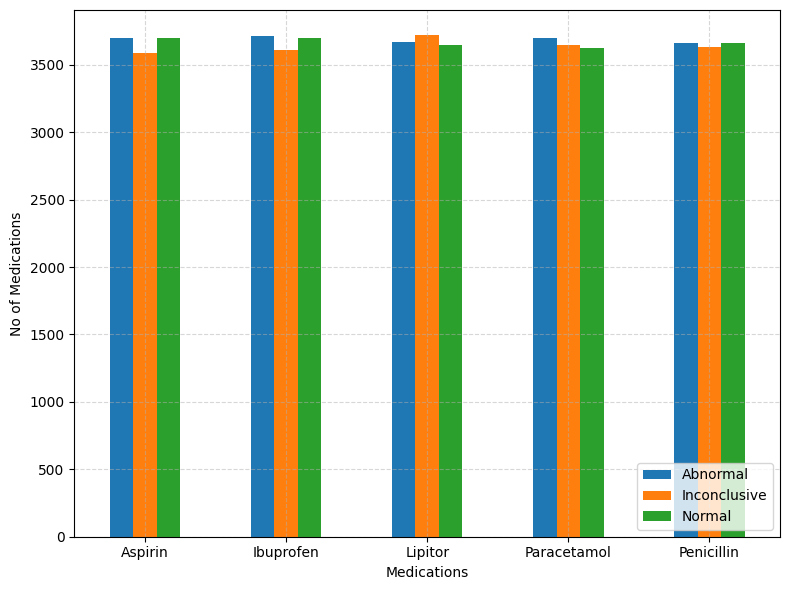

In [46]:
pivot=med_by_test_res
pivot.plot(kind="bar",figsize=(8,6))
plt.xlabel("Medications")
plt.xticks(rotation=0)
plt.ylabel("No of Medications")
plt.legend(loc="lower right")
plt.grid(linestyle="--",alpha=0.5)
plt.tight_layout()
plt.show()

In [47]:
days_by_test=df.groupby("Test Results")["Length of Stay"].mean()
print("Average staying day per Test Results:\n",days_by_test.round(2))

Average staying day per Test Results:
 Test Results
Abnormal        15.51
Inconclusive    15.45
Normal          15.54
Name: Length of Stay, dtype: float64


In [48]:
ad_type_med_con=df.groupby(["Medical Condition","Admission Type"]).size().unstack()
print(ad_type_med_con)
print("\nMost admission types in each medical condition:\n",ad_type_med_con.idxmax(axis=1))

Admission Type     Elective  Emergency  Urgent
Medical Condition                             
Arthritis              3062       3073    3083
Asthma                 3069       2978    3048
Cancer                 3114       2988    3038
Diabetes               3031       2988    3197
Hypertension           3182       2975    2994
Obesity                3015       3100    3031

Most admission types in each medical condition:
 Medical Condition
Arthritis          Urgent
Asthma           Elective
Cancer           Elective
Diabetes           Urgent
Hypertension     Elective
Obesity         Emergency
dtype: object


## Correlation Matrix

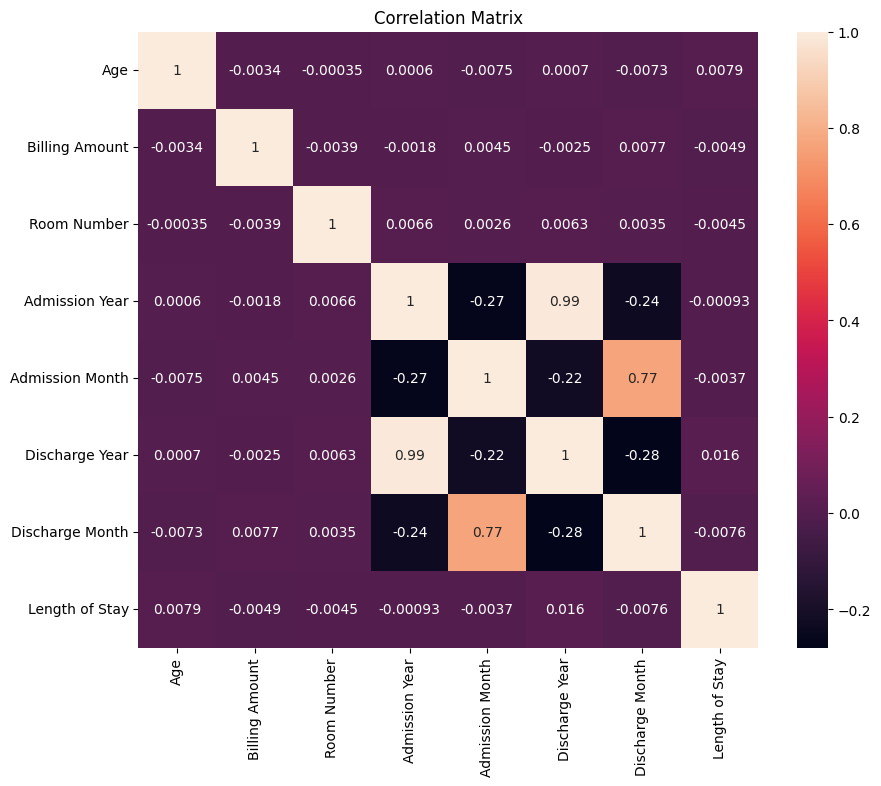

In [49]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

- The lack of strong linear correlations suggests that healthcare outcomes and costs in this dataset are influenced by multiple independent factors rather than a single dominant variable.